In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [24]:
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_excel('fear_greed_index.xlsx')

In [25]:
print(trades.shape)
print(sentiment.shape)


(211224, 16)
(2644, 4)


In [26]:
print(trades.isnull().sum())
print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [27]:
print(trades.duplicated().sum())
print(sentiment.duplicated().sum())


0
0


In [28]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date'], dayfirst=True).dt.date

In [29]:
df = pd.merge(trades, sentiment, on='date')

In [30]:
df['Closed PnL'] = pd.to_numeric(df['Closed PnL'], errors ='coerce')
df['Size USD'] = pd.to_numeric(df['Size USD'],errors = 'coerce')

df = df.drop_duplicates()
df = df.fillna(0)
    

In [31]:
daily_pnl = df.groupby('date')['Closed PnL'].sum()
print(daily_pnl.head())

date
2023-05-01      0.000000
2023-12-05      0.000000
2023-12-14   -205.434737
2023-12-15    -24.632034
2023-12-16      0.000000
Name: Closed PnL, dtype: float64


### 2.Win Rte

In [32]:
df['win'] = df['Closed PnL'] > 0
win_rate = df['win'].mean()
print('win_rate:', df['win'].mean())

win_rate: 0.41124809438589516


### 3.Trades per day 



In [33]:
trades_per_day = df.groupby('date').size()
print(trades_per_day.head())

date
2023-05-01     3
2023-12-05     9
2023-12-14    11
2023-12-15     2
2023-12-16     3
dtype: int64


### 4.Avg trade size

In [34]:
avg_size = df['Size USD'].mean()
print('Average Trade Size:' ,avg_size)

Average Trade Size: 5639.191610563493


### Q1.Fear vs Greed Profit

In [35]:
result = df.groupby('classification')['Closed PnL'].mean()
print(result)


classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


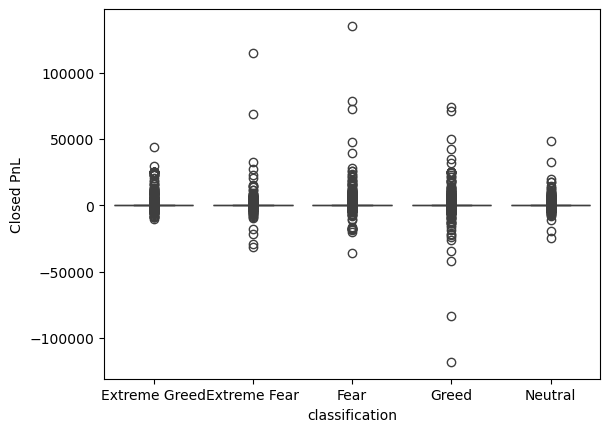

In [36]:
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.show()

### Q2.Behavior change

In [37]:
print(df.groupby('classification')['Size USD'].mean())
print(df.groupby('classification').size())

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64
classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


### Q3.Simple Segmentation


In [38]:
print(df.groupby('classification')['Closed PnL'].mean())
meadian_val = df['Size USD'].median()
df['trader_type'] = df['Size USD'] .apply(lambda x: 'High' if x > meadian_val else 'Low')
print(df['trader_type'].value_counts())

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64
trader_type
Low     105611
High    105607
Name: count, dtype: int64


## 1.Traders  earn more during  Greed days
## 2.Trade size is higher during Greed 
## 3.More trades happen during Greed

In [39]:
print(df.groupby('classification')['Closed PnL'].mean())
print(df.groupby('classification')['Size USD'].mean())
print(df.groupby('classification').size())

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64
classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64
classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


## Insight:
- Market sentiment has a direct impact on trader behavior. During Greed periods, traders show higher confidence by increasing trade size and frequency, which leads to higher overall profitability.

## Strategy Recommendations:
1. During Fear periods, traders should reduce position size and avoid high-risk trades to minimize losses.
2. During Greed periods, traders can increase participation, but must use proper risk management techniques like stop-loss to avoid overexposure.

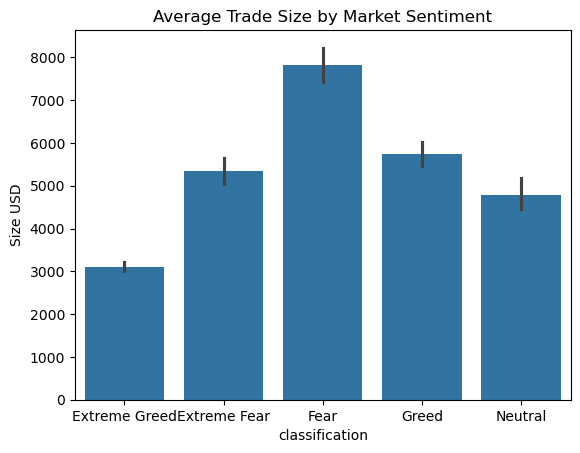

In [42]:
sns.barplot(x='classification', y='Size USD', data=df)
plt.title("Average Trade Size by Market Sentiment")
plt.show()

- This indicates that traders take higher risks and show increased participation during Greed market conditions


- During Fear -> Reduce trading activity and risk exposure
- During Greed -> Increease trading but maintain risk control